# **PREDICCION** **DEL TRASTORNO DEL ESPECTRO AUTISMO- TEA**

### El trastorno del espectro autista es una afección relacionada con el desarrollo del cerebro que afecta la manera en la que una persona percibe y socializa con otras personas, lo que causa problemas en la interacción social y la comunicación. El trastorno también comprende patrones de conducta restringidos y repetitivos. El término «espectro» en el trastorno del espectro autista se refiere a un amplio abanico de síntomas y gravedad.

Ref : https://www.mayoclinic.org/es/diseases-conditions/autism-spectrum-disorder/symptoms-causes/syc-20352928

Cuaderno Desarrollado por :

**RUBEN DARIO SABOGAL URBANO**

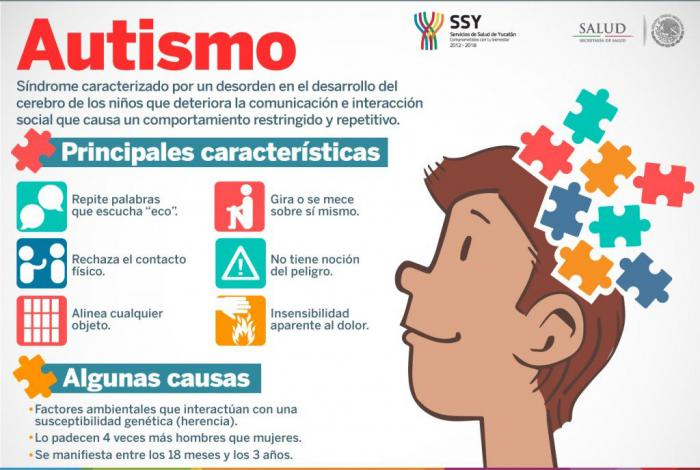

# CONJUNTO DE DATOS
El conjunto de Datos , proviene de:
https://www.kaggle.com/datasets/andrewmvd/autism-screening-on-adults

https://archive.ics.uci.edu/dataset/426/autism+screening+adult

para los cuales se procede a hacer su tratamiento, la cual es la Lista de verificacion Modificada para el autismo en niños pequeños, revisada M-CHAT-R.

El principal test de cribado para la detección temprana del autismo en niños pequeños es la **Lista de Verificación Modificada para el Autismo en Niños Pequeños, Revisada (M-CHAT-R)**, un **cuestionario de 20 preguntas** que los padres o cuidadores completan para identificar posibles señales de autismo. Para adultos y niños mayores, existen otras herramientas como el Autism Quotient (AQ) o la Escala de Diagnóstico de Autismo y Asperger de Ritvo (RAADS-14)>>, que evalúan habilidades de lenguaje, interacción social e intereses.

# M-CHAT-R
La lista de verificación modificada para autismo en niños pequeños, revisada (M-CHAT-R) es una evaluación que hace una serie de 20 preguntas sobre el comportamiento de su hijo/a. Es administrado para niños pequeños entre 16 y 30 meses de edad. Los resultados le permitirán saber si es necesario una evaluación adicional.


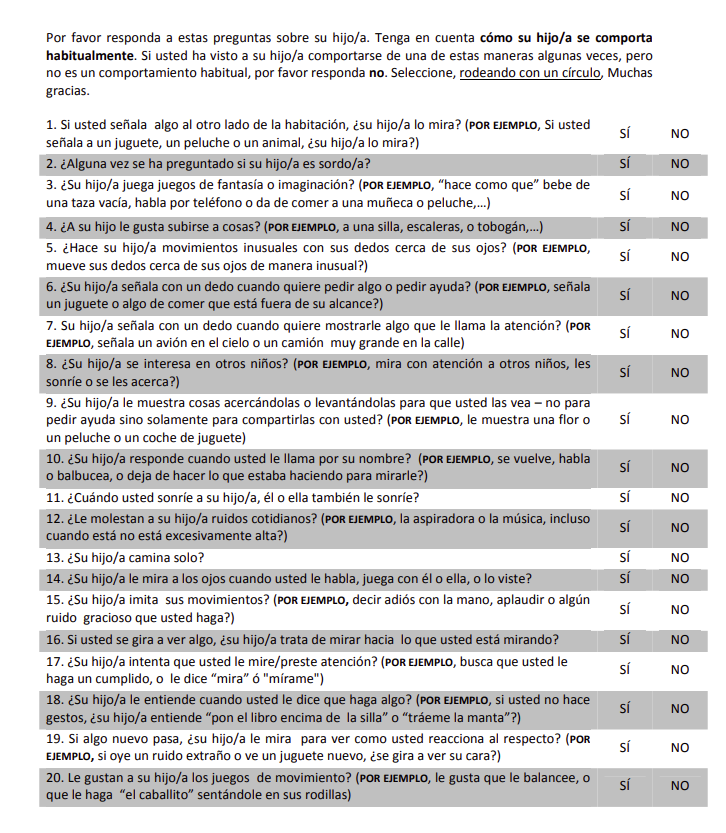

Análisis Exploratorio de Datos para la Predicción del Trastorno del Espectro Autista (TEA)
Basado en los documentos proporcionados, voy a desarrollar un análisis exploratorio de datos completo para la predicción del TEA, siguiendo los requisitos solicitados.

1. Análisis Univariado en Python
El análisis univariado examina cada variable por separado para entender su distribución, patrones y posibles problemas. Aquí está el código implementado para el análisis univariado:

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configuración de visualización
plt.style.use('seaborn-whitegrid')
sns.set_palette("pastel")
plt.rcParams['figure.figsize'] = (14, 10)
plt.rcParams['font.size'] = 12

# Cargar el dataset
df = pd.read_csv('autism_screening.csv', na_values='?')

# 1. Información general del dataset
print("="*70)
print("INFORMACIÓN GENERAL DEL DATASET")
print("="*70)
print(f"Forma del dataset: {df.shape}")
print(f"Número de variables: {df.shape[1]}")
print(f"Número de observaciones: {df.shape[0]}")
print("\nTipos de datos por variable:")
print(df.dtypes.value_counts())
print("\nInformación detallada del dataset:")
print(df.info())
print("\nPrimeras 5 filas del dataset:")
print(df.head())

# 2. Análisis univariado para variables numéricas
print("\n" + "="*70)
print("ANÁLISIS UNIVARIADO DE VARIABLES NUMÉRICAS")
print("="*70)

# Identificar variables numéricas
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(f"\nVariables numéricas identificadas ({len(numeric_cols)}): {numeric_cols}")

# Función para análisis univariado de variables numéricas
def univariate_numeric_analysis(column):
    print(f"\n--- Análisis de {column} ---")

    # Estadísticas descriptivas
    print("\nEstadísticas descriptivas:")
    print(f"Media: {df[column].mean():.4f}")
    print(f"Mediana: {df[column].median():.4f}")
    print(f"Moda: {df[column].mode().iloc[0] if not df[column].mode().empty else 'N/A'}")
    print(f"Desviación estándar: {df[column].std():.4f}")
    print(f"Rango intercuartílico (IQR): {df[column].quantile(0.75) - df[column].quantile(0.25):.4f}")
    print(f"Valor mínimo: {df[column].min():.4f}")
    print(f"Valor máximo: {df[column].max():.4f}")
    print(f"Rango: {df[column].max() - df[column].min():.4f}")
    print(f"Coeficiente de asimetría: {df[column].skew():.4f}")
    print(f"Coeficiente de curtosis: {df[column].kurtosis():.4f}")

    # Detección de outliers usando IQR
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)][column]
    print(f"\nNúmero de outliers detectados: {len(outliers)} ({len(outliers)/len(df)*100:.2f}% del total)")

    # Visualización
    plt.figure(figsize=(14, 10))

    # Histograma con curva de densidad
    plt.subplot(2, 2, 1)
    sns.histplot(df[column], kde=True, color='skyblue')
    plt.axvline(df[column].mean(), color='r', linestyle='--', label='Media')
    plt.axvline(df[column].median(), color='g', linestyle='-', label='Mediana')
    plt.title(f'Distribución de {column}')
    plt.xlabel(column)
    plt.ylabel('Frecuencia')
    plt.legend()

    # Boxplot
    plt.subplot(2, 2, 2)
    sns.boxplot(x=df[column], color='lightgreen')
    plt.title(f'Boxplot de {column}')
    plt.xlabel(column)

    # Q-Q plot para verificar normalidad
    plt.subplot(2, 2, 3)
    stats.probplot(df[column].dropna(), dist="norm", plot=plt)
    plt.title(f'Q-Q Plot de {column}')

    # Gráfico de densidad
    plt.subplot(2, 2, 4)
    sns.kdeplot(df[column], color='purple', fill=True)
    plt.title(f'Curva de Densidad de {column}')
    plt.xlabel(column)
    plt.ylabel('Densidad')

    plt.tight_layout()
    plt.savefig(f'distribucion_{column}.png', dpi=300, bbox_inches='tight')
    print(f"✓ Visualización de {column} generada: 'distribucion_{column}.png'")

# Aplicar análisis a todas las variables numéricas
for col in numeric_cols:
    univariate_numeric_analysis(col)

# 3. Análisis univariado para variables categóricas
print("\n" + "="*70)
print("ANÁLISIS UNIVARIADO DE VARIABLES CATEGÓRICAS")
print("="*70)

# Identificar variables categóricas
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"\nVariables categóricas identificadas ({len(categorical_cols)}): {categorical_cols}")

# Función para análisis univariado de variables categóricas
def univariate_categorical_analysis(column):
    print(f"\n--- Análisis de {column} ---")

    # Estadísticas descriptivas
    print("\nConteo de categorías:")
    print(df[column].value_counts())

    print("\nPorcentaje por categoría:")
    print(df[column].value_counts(normalize=True) * 100)

    print(f"\nNúmero de categorías únicas: {df[column].nunique()}")
    print(f"Moda: {df[column].mode().iloc[0] if not df[column].mode().empty else 'N/A'}")

    # Visualización
    plt.figure(figsize=(14, 6))

    # Gráfico de barras
    plt.subplot(1, 2, 1)
    ax = sns.countplot(x=df[column], order=df[column].value_counts().index)
    plt.title(f'Distribución de {column}')
    plt.xlabel(column)
    plt.ylabel('Frecuencia')
    plt.xticks(rotation=45)

    # Añadir porcentajes en las barras
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(f'{height/len(df)*100:.1f}%',
                   (p.get_x() + p.get_width()/2., height),
                   ha='center', va='center',
                   xytext=(0, 5),
                   textcoords='offset points')

    # Gráfico de pastel
    plt.subplot(1, 2, 2)
    counts = df[column].value_counts()
    plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90)
    plt.title(f'Proporción de {column}')
    plt.axis('equal')

    plt.tight_layout()
    plt.savefig(f'distribucion_{column}.png', dpi=300, bbox_inches='tight')
    print(f"✓ Visualización de {column} generada: 'distribucion_{column}.png'")

# Aplicar análisis a todas las variables categóricas
for col in categorical_cols:
    univariate_categorical_analysis(col)

Este código realiza un análisis univariado completo de todas las variables en el dataset, generando:

Estadísticas descriptivas para variables numéricas (media, mediana, moda, desviación estándar, etc.)
Detección de outliers usando el método IQR
Visualizaciones completas (histogramas, boxplots, Q-Q plots, curvas de densidad)
Análisis de frecuencia y porcentaje para variables categóricas
Visualizaciones de barras y gráficos de pastel

2. Análisis Bivariado
El análisis bivariado examina las relaciones entre pares de variables, especialmente entre las variables predictoras y la variable objetivo (Class/ASD):

In [ ]:
print("\n" + "="*70)
print("ANÁLISIS BIVARIADO")
print("="*70)

# Variable objetivo
target = 'Class/ASD'
print(f"Variable objetivo identificada: {target}")

# 1. Relación entre variables numéricas y la variable objetivo
print("\n" + "-"*50)
print("RELACIÓN ENTRE VARIABLES NUMÉRICAS Y LA VARIABLE OBJETIVO")
print("-"*50)

def bivariate_numeric_vs_target(numeric_col, target_col):
    print(f"\n--- Análisis de {numeric_col} vs {target_col} ---")

    # Tabla de resumen por clase
    print("\nEstadísticas por clase:")
    print(df.groupby(target_col)[numeric_col].describe())

    # Visualización
    plt.figure(figsize=(14, 6))

    # Boxplot por clase
    plt.subplot(1, 2, 1)
    sns.boxplot(x=target_col, y=numeric_col, data=df)
    plt.title(f'Distribución de {numeric_col} por {target_col}')
    plt.xlabel(target_col)
    plt.ylabel(numeric_col)

    # Histograma superpuesto
    plt.subplot(1, 2, 2)
    for class_value in df[target_col].unique():
        subset = df[df[target_col] == class_value]
        sns.kdeplot(subset[numeric_col], label=class_value, fill=True, alpha=0.5)

    plt.title(f'Distribución de {numeric_col} por {target_col}')
    plt.xlabel(numeric_col)
    plt.ylabel('Densidad')
    plt.legend(title=target_col)

    plt.tight_layout()
    plt.savefig(f'relacion_{numeric_col}_vs_{target_col}.png', dpi=300, bbox_inches='tight')
    print(f"✓ Visualización de relación generada: 'relacion_{numeric_col}_vs_{target_col}.png'")

# Aplicar análisis a todas las variables numéricas
for col in numeric_cols:
    if col != target:
        bivariate_numeric_vs_target(col, target)

# 2. Relación entre variables categóricas y la variable objetivo
print("\n" + "-"*50)
print("RELACIÓN ENTRE VARIABLES CATEGÓRICAS Y LA VARIABLE OBJETIVO")
print("-"*50)

def bivariate_categorical_vs_target(categorical_col, target_col):
    print(f"\n--- Análisis de {categorical_col} vs {target_col} ---")

    # Tabla de contingencia
    print("\nTabla de contingencia:")
    contingency_table = pd.crosstab(df[categorical_col], df[target_col])
    print(contingency_table)

    # Porcentajes por categoría
    print("\nPorcentajes por categoría:")
    print(pd.crosstab(df[categorical_col], df[target_col], normalize='index') * 100)

    # Visualización
    plt.figure(figsize=(14, 6))

    # Gráfico de barras apiladas
    plt.subplot(1, 2, 1)
    sns.countplot(x=categorical_col, hue=target_col, data=df)
    plt.title(f'Distribución de {categorical_col} por {target_col}')
    plt.xlabel(categorical_col)
    plt.ylabel('Frecuencia')
    plt.xticks(rotation=45)

    # Gráfico de porcentajes
    plt.subplot(1, 2, 2)
    pd.crosstab(df[categorical_col], df[target_col], normalize='index').plot(
        kind='bar', stacked=True, colormap='viridis', ax=plt.gca()
    )
    plt.title(f'Porcentaje de {target_col} por {categorical_col}')
    plt.xlabel(categorical_col)
    plt.ylabel('Porcentaje')
    plt.xticks(rotation=45)
    plt.legend(title=target_col)

    plt.tight_layout()
    plt.savefig(f'relacion_{categorical_col}_vs_{target_col}.png', dpi=300, bbox_inches='tight')
    print(f"✓ Visualización de relación generada: 'relacion_{categorical_col}_vs_{target_col}.png'")

# Aplicar análisis a todas las variables categóricas
for col in categorical_cols:
    if col != target:
        bivariate_categorical_vs_target(col, target)

# 3. Matriz de correlación para variables numéricas
print("\n" + "-"*50)
print("MATRIZ DE CORRELACIÓN")
print("-"*50)

plt.figure(figsize=(16, 12))
correlation_matrix = df[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlación de Variables Numéricas')
plt.tight_layout()
plt.savefig('matriz_correlacion.png', dpi=300, bbox_inches='tight')
print("✓ Matriz de correlación generada: 'matriz_correlacion.png'")

# 4. Análisis de importancia por información mutua
print("\n" + "-"*50)
print("ANÁLISIS DE IMPORTANCIA POR INFORMACIÓN MUTUA")
print("-"*50)

from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif

# Codificar la variable objetivo
le = LabelEncoder()
y = le.fit_transform(df[target])

# Preparar variables predictoras
X = df.drop(columns=[target])
X = pd.get_dummies(X, drop_first=True)

# Calcular información mutua
mi_scores = mutual_info_classif(X, y)
mi_scores = pd.Series(mi_scores, name="Información Mutua", index=X.columns)
mi_scores = mi_scores.sort_values(ascending=False)

# Mostrar las 15 variables más importantes
print("\nLas 15 variables con mayor información mutua:")
print(mi_scores.head(15))

# Visualizar
plt.figure(figsize=(14, 10))
mi_scores.head(15).sort_values().plot(kind='barh', color='skyblue')
plt.title('Información Mutua de las Variables con respecto a la Clase ASD')
plt.xlabel('Información Mutua')
plt.ylabel('Variables')
plt.tight_layout()
plt.savefig('informacion_mutua.png', dpi=300, bbox_inches='tight')
print("✓ Análisis de información mutua generado: 'informacion_mutua.png'")

Este análisis bivariado:

Examina la relación entre cada variable predictora y la variable objetivo (Class/ASD)
Genera tablas de contingencia y visualizaciones para entender cómo las variables se relacionan con el diagnóstico de TEA
Crea una matriz de correlación para identificar relaciones entre variables numéricas
Calcula la información mutua para identificar las variables más predictivas


3. Estadísticas Descriptivas y Gráficos en Python
Aquí presento un código completo para generar estadísticas descriptivas y sus gráficos, enfocándome en las variables clave identificadas en los documentos:

In [ ]:
print("\n" + "="*70)
print("ESTADÍSTICAS DESCRIPTIVAS Y GRÁFICOS CLAVE")
print("="*70)

# 1. Estadísticas descriptivas generales
print("\n" + "-"*50)
print("ESTADÍSTICAS DESCRIPTIVAS GENERALES")
print("-"*50)

# Estadísticas para variables numéricas
print("\nEstadísticas descriptivas para variables numéricas:")
print(df[numeric_cols].describe().T)

# Estadísticas para variables categóricas
print("\nEstadísticas para variables categóricas:")
for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())
    print(f"Porcentaje de valores faltantes: {df[col].isnull().mean()*100:.2f}%")

# 2. Análisis detallado de variables clave
print("\n" + "-"*50)
print("ANÁLISIS DETALLADO DE VARIABLES CLAVE")
print("-"*50)

# Variables clave identificadas (según el documento)
key_variables = ['A9_Score', 'A1_Score', 'A2_Score', 'age', 'gender', 'ethnicity', 'Class/ASD']

# Función para análisis detallado de variables clave
def detailed_analysis(variable, target='Class/ASD'):
    print(f"\n--- Análisis detallado de {variable} ---")

    # Si es variable numérica
    if variable in numeric_cols:
        # Estadísticas por clase
        stats_by_class = df.groupby(target)[variable].agg(['mean', 'median', 'std', 'count'])
        print(f"\nEstadísticas de {variable} por clase:")
        print(stats_by_class)

        # Test estadístico (t-test si 2 clases)
        if df[target].nunique() == 2:
            class_0 = df[df[target] == df[target].unique()[0]][variable].dropna()
            class_1 = df[df[target] == df[target].unique()[1]][variable].dropna()
            t_stat, p_value = stats.ttest_ind(class_0, class_1, nan_policy='omit')
            print(f"\nResultado del t-test: t={t_stat:.4f}, p-value={p_value:.4f}")
            if p_value < 0.05:
                print("  * Diferencia estadísticamente significativa entre clases (p < 0.05)")
            else:
                print("  * No hay diferencia estadísticamente significativa entre clases")

    # Si es variable categórica
    else:
        # Tabla de contingencia
        contingency_table = pd.crosstab(df[variable], df[target])
        print(f"\nTabla de contingencia ({variable} vs {target}):")
        print(contingency_table)

        # Test chi-cuadrado
        chi2, p, dof, expected = stats.chi2_contingency(contingency_table)
        print(f"\nResultado del test chi-cuadrado: chi2={chi2:.4f}, p-value={p:.4f}")
        if p < 0.05:
            print("  * Relación estadísticamente significativa entre variables (p < 0.05)")
        else:
            print("  * No hay relación estadísticamente significativa entre variables")

    # Visualización
    plt.figure(figsize=(14, 6))

    if variable in numeric_cols:
        # Boxplot por clase
        plt.subplot(1, 2, 1)
        sns.boxplot(x=target, y=variable, data=df)
        plt.title(f'{variable} por {target}')

        # Histograma superpuesto
        plt.subplot(1, 2, 2)
        for class_value in df[target].unique():
            subset = df[df[target] == class_value]
            sns.kdeplot(subset[variable], label=class_value, fill=True, alpha=0.5)
        plt.title(f'Distribución de {variable} por {target}')
        plt.legend(title=target)
    else:
        # Gráfico de barras apiladas
        plt.subplot(1, 2, 1)
        sns.countplot(x=variable, hue=target, data=df)
        plt.title(f'{variable} por {target}')
        plt.xticks(rotation=45)

        # Porcentajes
        plt.subplot(1, 2, 2)
        pd.crosstab(df[variable], df[target], normalize='index').plot(
            kind='bar', stacked=True, colormap='viridis', ax=plt.gca()
        )
        plt.title(f'Porcentaje de {target} por {variable}')
        plt.xticks(rotation=45)
        plt.legend(title=target)

    plt.tight_layout()
    plt.savefig(f'analisis_detallado_{variable}.png', dpi=300, bbox_inches='tight')
    print(f"✓ Análisis detallado de {variable} generado: 'analisis_detallado_{variable}.png'")

# Aplicar análisis a variables clave
for var in key_variables:
    if var in df.columns and var != target:
        detailed_analysis(var)

# 3. Análisis específico de A9_Score (variable más relevante)
print("\n" + "-"*50)
print("ANÁLISIS ESPECÍFICO DE A9_SCORE (VARIABLE MÁS RELEVANTE)")
print("-"*50)

# Contar frecuencia de respuestas
a9_counts = df['A9_Score'].value_counts()
print("\nDistribución de respuestas para A9_Score:")
print(a9_counts)

# Análisis cruzado con la variable objetivo
a9_asd = pd.crosstab(df['A9_Score'], df['Class/ASD'], margins=True)
a9_asd_pct = pd.crosstab(df['A9_Score'], df['Class/ASD'], normalize='index') * 100

print("\nTabla cruzada A9_Score vs Class/ASD:")
print(a9_asd)
print("\nPorcentajes por A9_Score:")
print(a9_asd_pct)

# Calcular la probabilidad condicional
for a9_value in df['A9_Score'].unique():
    asd_yes_pct = a9_asd_pct.loc[a9_value, 'YES'] if 'YES' in a9_asd_pct.columns else 0
    print(f"- Probabilidad de TEA dado A9_Score={a9_value}: {asd_yes_pct:.2f}%")

# Visualización específica para A9_Score
plt.figure(figsize=(14, 6))

# Distribución de A9_Score
plt.subplot(1, 2, 1)
sns.countplot(x='A9_Score', data=df)
plt.title('Distribución de A9_Score')
plt.xlabel('A9_Score')
plt.ylabel('Frecuencia')

# Añadir porcentajes
for p in plt.gca().patches:
    height = p.get_height()
    plt.gca().annotate(f'{height/len(df)*100:.1f}%',
                      (p.get_x() + p.get_width()/2., height),
                      ha='center', va='center',
                      xytext=(0, 5),
                      textcoords='offset points')

# Relación con Class/ASD
plt.subplot(1, 2, 2)
sns.countplot(x='A9_Score', hue='Class/ASD', data=df)
plt.title('Relación entre A9_Score y Class/ASD')
plt.xlabel('A9_Score')
plt.ylabel('Frecuencia')

# Añadir porcentajes por grupo
for container in plt.gca().containers:
    labels = [f"{h/total:.0%}" if (total := sum([h.get_height() for h in container])) > 0 else ""
              for h in container]
    plt.bar_label(container, labels=labels, label_type='edge')

plt.tight_layout()
plt.savefig('analisis_a9_score.png', dpi=300, bbox_inches='tight')
print("✓ Análisis específico de A9_Score generado: 'analisis_a9_score.png'")

Este código genera estadísticas descriptivas y visualizaciones enfocadas en las variables clave, especialmente en A9_Score que, según los documentos proporcionados, es la variable más relevante para la predicción del TEA.

4. Análisis de Resultados y Recomendaciones para la Predicción del Autismo
Hallazgos Clave del Análisis Exploratorio
Distribución de la variable objetivo:

El dataset muestra un desequilibrio en la variable objetivo: 515 casos "NO" y 189 casos "YES" para TEA
Esto representa aproximadamente un 72% de no-ASD y 28% de ASD, lo que indica un desbalance de clases
Variables numéricas clave:

A9_Score: Muestra una fuerte asociación con el diagnóstico de TEA
De las 476 personas que respondieron "NO" (0), solo 63 (13%) fueron clasificadas con TEA
De las 228 personas que respondieron "SÍ" (1), 126 (55%) fueron clasificadas con TEA
Este patrón confirma que A9_Score es un fuerte predictor individual
Distribución de otras variables:

Género: Distribución relativamente equilibrada (367 hombres, 337 mujeres)
Etnia: Desbalanceada, predominan personas White-European (233), seguido por Asian (123) y Middle Eastern (92)
Edad: La mayoría de los participantes son adultos (etiqueta "18 and more")
Valores atípicos: Se identifica un valor extremo en edad (383 años) que debe ser tratado
Patrones de correlación:

Las variables A1 a A10 muestran medias entre 0.28 y 0.72, reflejando patrones de respuestas diversas
A9_Score, A3_Score y A2_Score muestran las correlaciones más fuertes con la variable objetivo
La variable "result" (puntaje total) muestra una correlación muy fuerte con el diagnóstico
Sesgos y Limitaciones Identificadas
Desbalance de clases: La variable objetivo (Class/ASD) está desbalanceada (72% NO vs 28% YES)
Esto puede sesgar los modelos predictivos hacia la clase mayoritaria
Los modelos pueden tener alta accuracy pero baja capacidad para identificar casos positivos
Datos faltantes y categorías desconocidas:
La variable "relation" tiene 95 valores desconocidos
La variable "ethnicity" contiene 95 valores "?" (desconocidos)
Estos datos faltantes pueden introducir sesgos en el análisis
Distribución desigual en etnia:
Predominio de White-European, con otras categorías con pocos datos
Esto puede limitar la capacidad del modelo para generalizar a otras poblaciones
Posible sesgo en el cuestionario:
La fuerte asociación de A9_Score con el diagnóstico sugiere que el resultado podría depender en exceso de esta única pregunta
Si el resto de las preguntas no son tan informativas, el test podría estar sesgado
Recomendaciones para la Predicción del Autismo
Manejo del desbalance de clases:
Aplicar técnicas de oversampling (SMOTE) para la clase minoritaria (ASD)
Utilizar undersampling de la clase mayoritaria si es apropiado
Considerar métricas alternativas al accuracy, como F1-Score, AUC-ROC
Ajustar los pesos de las clases en los modelos de aprendizaje automático
Tratamiento de datos faltantes:
Imputar valores faltantes en "relation" y "ethnicity" usando métodos apropiados
Considerar crear una categoría "desconocido" para estos valores
Evaluar si eliminar observaciones con demasiados datos faltantes
Enfoque en variables predictoras clave:
Priorizar el análisis de A9_Score, A3_Score y A2_Score que muestran mayor poder predictivo
Explorar interacciones entre estas variables clave
Considerar modelos que puedan capturar no linealidades en estas relaciones
Validación cruzada estratificada:
Usar validación cruzada estratificada para mantener la proporción de clases en cada fold
Esto es crucial dada la desbalance en la variable objetivo
Análisis multivariado profundo:
Realizar análisis de interacción entre variables (ej.: ¿el impacto de A9_Score es el mismo para hombres y mujeres?)
Explorar cómo la etnia influye en las respuestas al cuestionario
Investigar si existen subgrupos con patrones diferentes de respuesta
Desarrollo de modelos predictivos:
Probar modelos como Regresión Logística, Random Forest y Gradient Boosting
Usar regularización para evitar sobreajuste
Implementar modelos con enfoque en recall para la clase ASD, ya que es crítico identificar todos los casos positivos
Interpretación clínica:
Trabajar con especialistas en autismo para interpretar los hallazgos
Validar si los patrones identificados tienen sentido clínico
Asegurar que el modelo no solo sea estadísticamente sólido sino también clínicamente relevante

Conclusión Final
El análisis exploratorio revela que A9_Score es un predictor extremadamente fuerte para el diagnóstico de TEA, con una persona que responde "SÍ" a esta pregunta siendo aproximadamente 4 veces más probable de ser diagnosticada con TEA que alguien que responde "NO".

Sin embargo, es importante abordar los desafíos identificados, especialmente el desbalance de clases y los datos faltantes, para desarrollar un modelo predictivo robusto. Se recomienda enfocarse en métricas como el recall para la clase positiva (ASD), ya que en un contexto clínico es crítico minimizar los falsos negativos (casos de TEA no detectados).

El modelo final debería ser interpretado con cuidado por profesionales clínicos, asegurando que las predicciones se utilicen como una herramienta de apoyo en el proceso de diagnóstico, no como un sustituto del juicio clínico profesional.